# Задача:
0. Описать задачу словами
1. Прочитать данные
2. Провести разведочный анализ данных (EDA): Визуализировать данные и вычислить основные характеристики (среднее, разброс, корреляционную матрицу и т.д.). Интерпретировать.
3. Обработать пропущенные значения (или убедиться, что их нет)
4. Обработать категориальные признаки
5. Провести нормализацию (или объяснить, почему в вашем случае она не нужна)
6. Разбить данные на обучающую и тестовую выборки
7. Запустить классификатор ближайших соседей или другой (аргументировать свой выбор)
8. Подобрать оптимальное значение к-ва ближайших соседей (или другого релевантного гиперпараметра)
9. Вычислить ошибки на обучающей и тестовой выборках. Сделать выводы
10. Запустить другие классификаторы и выбрать параметры. Выбрать релевантные! Сравнить результаты
11. Как-то побороться с несбалансированностью классов (если она есть)
12. Исключить коррелированные переменные (объяснить зачем)
13. Сделать общие выводы

# 0. Описать задачу словами
Дан датасет, содержащий 17 признаков, которые описывают характеристики композиций. Требуется определить жанр композиции из списка(Rock, Indie, Alt, Pop, Metal, HipHop, Alt_Music, Blues, Acoustic/Folk, Instrumental, Country) Датасет содежит ~18 000 объектов. Описание признаков:

1. Автор (строковый)
2. Название (строковый)
3. Популярность (числовой)
4. Танцевальность (числовой)
5. Энергичность (числовой)
6. Тональность (числовой)
7. Громкость (числовой)
8. Лад (числовой)
9. Разговорность (числовой)
10. Акустика (числовой)
11. Инструментальность (числовой)
12. Живость (числовой)
13. Валентность (числовой)
14. Темп (числовой)
15. Длительность в минутах/милисекундах (числовой)
16. Тактовый размер (числовой)
17. Жанр, из пронумерованного списка (числовой/категориальный)

# 1. Чтение данных

In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error

# Чтение данных
# https://www.kaggle.com/datasets/purumalgi/music-genre-classification
data = pd.read_csv("./train.csv")

# Вывод базовой инфомации
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         17996 non-null  object 
 1   Track Name          17996 non-null  object 
 2   Popularity          17568 non-null  float64
 3   danceability        17996 non-null  float64
 4   energy              17996 non-null  float64
 5   key                 15982 non-null  float64
 6   loudness            17996 non-null  float64
 7   mode                17996 non-null  int64  
 8   speechiness         17996 non-null  float64
 9   acousticness        17996 non-null  float64
 10  instrumentalness    13619 non-null  float64
 11  liveness            17996 non-null  float64
 12  valence             17996 non-null  float64
 13  tempo               17996 non-null  float64
 14  duration_in min/ms  17996 non-null  float64
 15  time_signature      17996 non-null  int64  
 16  Clas

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.017100,NaN,0.0849,0.8990,134.071,234596.0,4,5
1,Boston,Hitch a Ride,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,4,10
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,4,6
3,Deno,Lingo (feat. J.I & Chunkz),66.0,0.853,0.597,10.0,-6.528,0,0.0555,0.021200,NaN,0.1220,0.5690,107.033,173968.0,4,5
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,4,10


In [2]:
num_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = data.select_dtypes(include=["object"]).columns.tolist()
print(f"Числовые признаки: {num_cols}")
print(f"Категориальные признаки: {cat_cols}")

Числовые признаки: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Class']
Категориальные признаки: ['Artist Name', 'Track Name']


# 2. EDA. Основные характеистики данных. Их интерпретация
2.1 Основные характеистики числовых признаков

In [3]:
data.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,17568.000000,17996.000000,17996.000000,15982.000000,17996.000000,17996.000000,17996.000000,17996.000000,13619.000000,17996.000000,17996.000000,17996.000000,1.799600e+04,17996.000000,17996.000000
mean,44.512124,0.543433,0.662777,5.952447,-7.910660,0.636753,0.079707,0.247082,0.177562,0.196170,0.486208,122.623294,2.007445e+05,3.924039,6.695821
std,17.426928,0.166268,0.235373,3.196854,4.049151,0.480949,0.083576,0.310632,0.304048,0.159212,0.240195,29.571527,1.119891e+05,0.361618,3.206073
min,1.000000,0.059600,0.000020,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.018300,30.557000,5.016500e-01,1.000000,0.000000
25%,33.000000,0.432000,0.509000,3.000000,-9.538000,0.000000,0.034800,0.004300,0.000089,0.097500,0.297000,99.620750,1.663370e+05,4.000000,5.000000
50%,44.000000,0.545000,0.700000,6.000000,-7.016000,1.000000,0.047400,0.081400,0.003910,0.129000,0.481000,120.065500,2.091600e+05,4.000000,8.000000
75%,56.000000,0.659000,0.860000,9.000000,-5.189000,1.000000,0.083000,0.434000,0.200000,0.258000,0.672000,141.969250,2.524900e+05,4.000000,10.000000
max,100.000000,0.989000,1.000000,11.000000,1.355000,1.000000,0.955000,0.996000,0.996000,1.000000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


2.2 Основные статистики по категориальным признакам

In [4]:
data.describe(include=["object"])

,Artist Name,Track Name
count,17996,17996
unique,9149,15129
top,Backstreet Boys,Dreams
freq,69,9


In [5]:
# Удалим слишком уникальные признаки (то есть признаки, которые почти никак не группиуют данные) 
data = data.drop(columns= ['Artist Name', 'Track Name'])

num_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = data.select_dtypes(include=["object"]).columns.tolist()
print(f"Числовые признаки: {num_cols}")
print(f"Категориальные признаки: {cat_cols}")

Числовые признаки: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Class']
Категориальные признаки: []


2.3 Диаграммы рассеивания числовых признаков относительно жанра

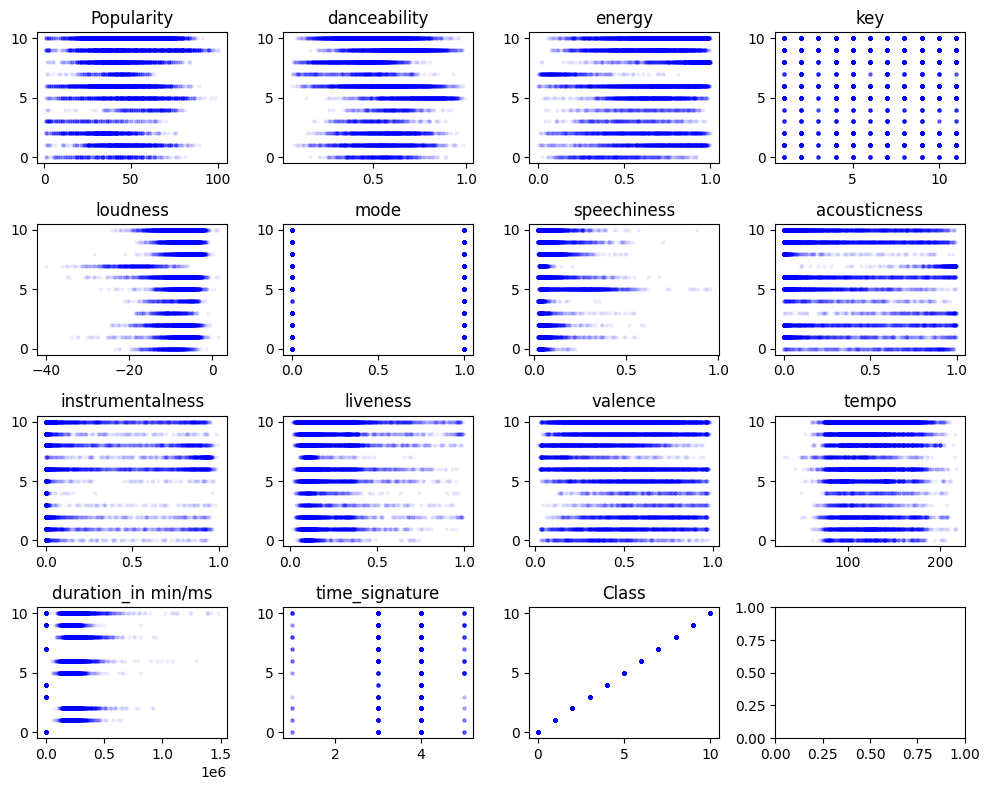

In [6]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 8))
xx, yy = 0, 0
for col in num_cols:
    axes[xx, yy].scatter(x=data[col], y=data["Class"], alpha=0.05, color='blue', s=5)
    axes[xx, yy].set_title(col)
    yy+=1
    if(yy == 4):
        xx += 1
        yy = 0
plt.tight_layout()
plt.show()

2.4 Матрица корреляций

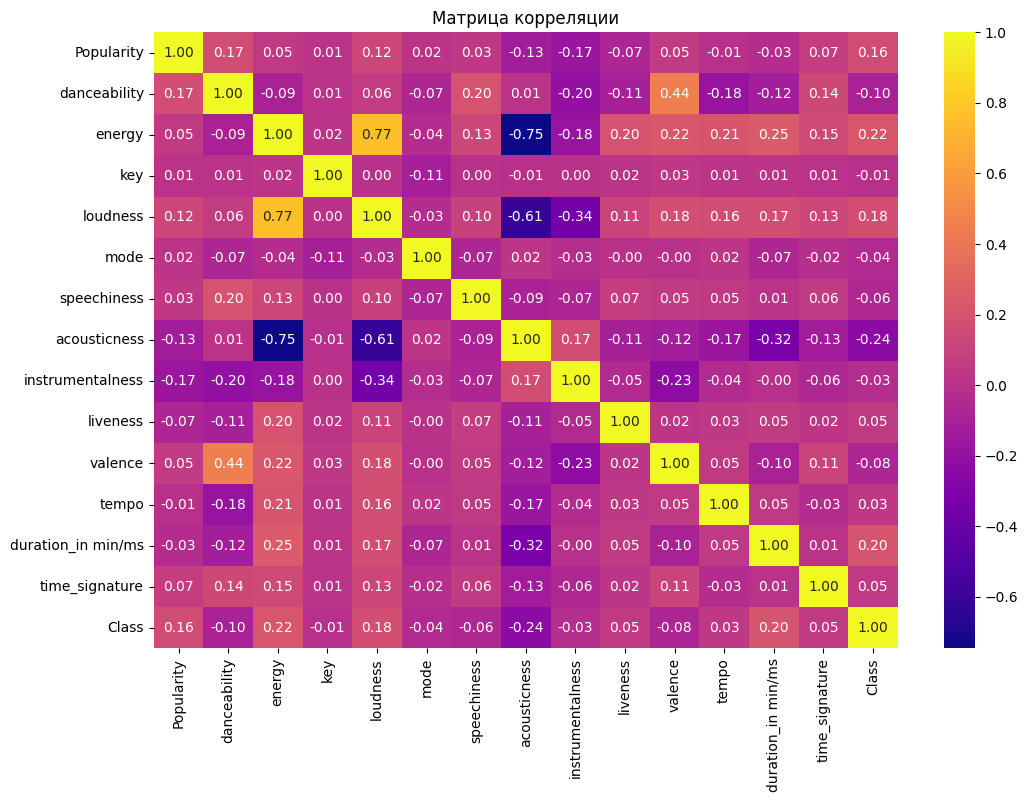

In [7]:
corr_matrix_numeric = data.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_numeric, annot= True, cmap='plasma', fmt='.2f')
plt.title("Матрица корреляции")
plt.show()

2.5 Высокая положительная корреляция следующих параметров композиции:
- energy
- loudness

Интерпретация: более энергичная музыка обычно более громкая

Высокая отрицательная корелляция следующих параметров композиции:
- acousticness и loudness
- acousticness и energy

Интерпретация: композиции с хорошей акустикой чаще менее энергичные и громкие

# 3. Обработка пропущенных значений

In [8]:
missing_percent = data.isna().mean() * 100
print("\nПропущенные значения (%):")
print(missing_percent.sort_values(ascending=False))


Пропущенные значения (%):
instrumentalness      24.322072
key                   11.191376
Popularity             2.378306
danceability           0.000000
energy                 0.000000
loudness               0.000000
mode                   0.000000
speechiness            0.000000
acousticness           0.000000
liveness               0.000000
valence                0.000000
tempo                  0.000000
duration_in min/ms     0.000000
time_signature         0.000000
Class                  0.000000
dtype: float64


In [9]:
data_with_nulls = data[data['instrumentalness'].isnull() | data['key'].isnull() | data['Popularity'].isnull()]

In [10]:
data_with_nulls.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,5755.000000,6183.000000,6183.000000,4169.000000,6183.000000,6183.000000,6183.000000,6183.000000,1806.000000,6183.000000,6183.000000,6183.000000,6.183000e+03,6183.000000,6183.000000
mean,47.409383,0.578758,0.648394,5.895419,-7.327658,0.661168,0.096138,0.260672,0.168212,0.198222,0.516956,122.039909,1.774354e+05,3.943555,6.835678
std,18.739583,0.160969,0.220795,3.278734,3.586483,0.473351,0.105556,0.293234,0.305527,0.158184,0.228364,29.832094,1.001613e+05,0.319054,3.122565
min,1.000000,0.059600,0.001210,1.000000,-39.952000,0.000000,0.023000,0.000002,0.000001,0.021900,0.022300,47.387000,5.339167e-01,1.000000,0.000000
25%,34.000000,0.473000,0.502000,3.000000,-8.809000,0.000000,0.035300,0.016600,0.000054,0.098600,0.345000,97.595000,1.500365e+05,4.000000,5.000000
50%,47.000000,0.579000,0.675000,6.000000,-6.565000,1.000000,0.050000,0.129000,0.002010,0.133000,0.509000,120.151000,1.946430e+05,4.000000,8.000000
75%,61.000000,0.691000,0.825000,9.000000,-4.967500,1.000000,0.102000,0.449500,0.145750,0.262000,0.697000,142.040000,2.303130e+05,4.000000,10.000000
max,100.000000,0.974000,0.998000,11.000000,0.943000,1.000000,0.955000,0.995000,0.964000,1.000000,0.986000,209.840000,1.392667e+06,5.000000,10.000000


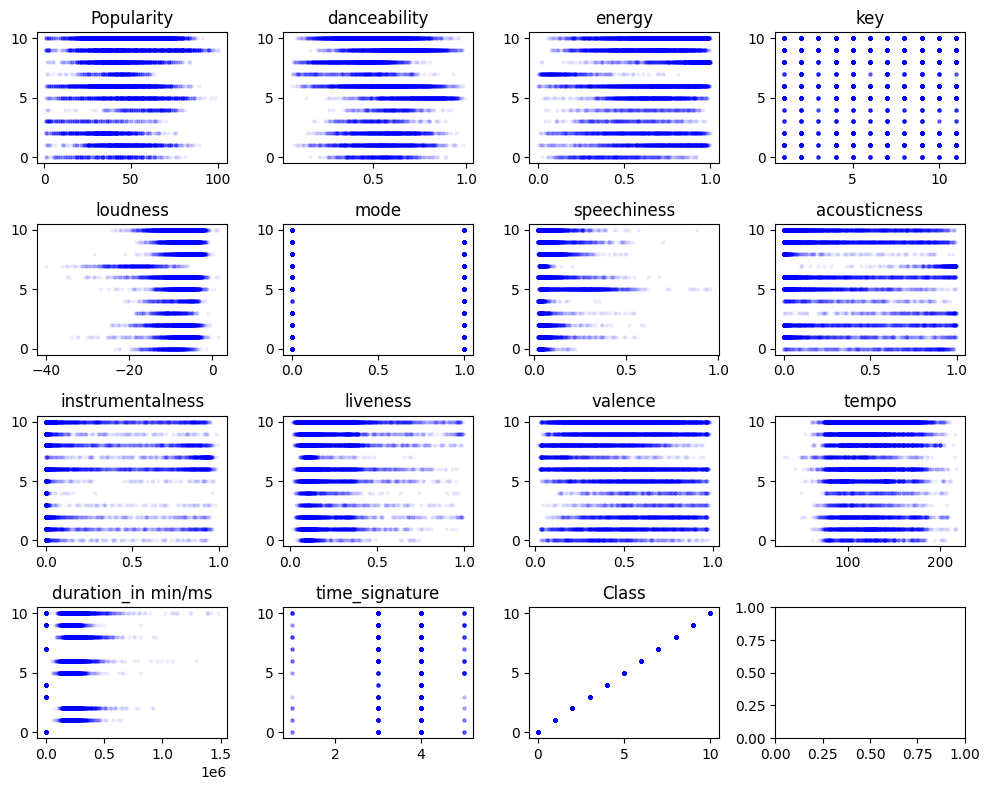

In [11]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 8))
xx, yy = 0, 0
for col in num_cols:
    axes[xx, yy].scatter(x=data[col], y=data["Class"], alpha=0.05, color='blue', s=5)
    axes[xx, yy].set_title(col)
    yy+=1
    if(yy == 4):
        xx += 1
        yy = 0
plt.tight_layout()
plt.show()

Диаграммы идентичны полученным по полному набору данных, поэтому можно избавиться от лишних(неполных) строк.

In [12]:
data = data.dropna(subset=['instrumentalness', 'key', 'Popularity'])

In [13]:
missing_percent = data.isna().mean() * 100
print("\nПропущенные значения (%):")
print(missing_percent.sort_values(ascending=False))


Пропущенные значения (%):
Popularity            0.0
danceability          0.0
energy                0.0
key                   0.0
loudness              0.0
mode                  0.0
speechiness           0.0
acousticness          0.0
instrumentalness      0.0
liveness              0.0
valence               0.0
tempo                 0.0
duration_in min/ms    0.0
time_signature        0.0
Class                 0.0
dtype: float64


# 4. Обработка категориальных признаков
Столбец жанра, является закодированным с помощью нумерованного списка. Нужно перевести его в OneHotEncoder.

In [14]:
# Кодирование категориальных признаков
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

copy = data.copy()

encoded_ndarr = encoder.fit_transform(copy[["Class"]])

target = ['Rock', 'Indie', 'Alt', 'Pop', 'Metal', 'HipHop', 'Alt_Music', 'Blues', 'Acoustic/Folk', 'Instrumental', 'Country']

encoded_data_cat = pd.DataFrame(
    encoded_ndarr,
    columns = target,
    index = copy.index
)

encoded_data_cat.head()

encoded_data = pd.concat([copy[num_cols], encoded_data_cat], axis=1)

encoded_data.head()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,Indie,Alt,Pop,Metal,HipHop,Alt_Music,Blues,Acoustic/Folk,Instrumental,Country
1,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.004010,0.1010,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.000196,0.3940,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,53.0,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.016100,0.1720,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,53.0,0.235,0.977,6.0,0.878,1,0.1070,0.003530,0.006040,0.1720,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,48.0,0.674,0.658,5.0,-9.647,0,0.1040,0.404000,0.000001,0.0981,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
data = encoded_data

# 5. Нормализация числовых признаков

In [16]:
# номализация числовых признаков
scaler = StandardScaler()

num_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

num_cols.remove("Class")
for col in target:
    num_cols.remove(col)

encoded_and_normalized_data = encoded_data.copy()
encoded_and_normalized_data[num_cols] = scaler.fit_transform(encoded_data[num_cols])

encoded_and_normalized_data = pd.DataFrame(
    encoded_and_normalized_data,
    columns=encoded_and_normalized_data.columns,
    index=encoded_data.index
)

encoded_and_normalized_data.head()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,Indie,Alt,Pop,Metal,HipHop,Alt_Music,Blues,Acoustic/Folk,Instrumental,Country
1,0.657863,-0.861080,0.593013,-0.938545,0.232529,0.776294,-0.450090,-0.748501,-0.575982,-0.589070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.488940,-0.547837,-0.232364,0.008660,-0.027879,0.776294,-0.274522,0.770948,-0.588537,1.245203,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.597505,-2.156218,1.257441,-1.254280,0.928601,0.776294,2.137688,-0.751419,-0.536186,-0.144588,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.597505,-1.746593,1.265694,0.008660,2.145018,0.776294,0.529548,-0.740887,-0.569300,-0.144588,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,0.295715,0.897898,-0.050781,-0.307075,-0.337585,-1.288172,0.485287,0.513999,-0.589178,-0.607225,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 6. Разбиение данных на обучающую и тестовую выборки

In [17]:
#  X - признаки, Y - вектор целевой переменной
X = encoded_and_normalized_data.drop(columns=["Class"] + target, axis = 1)
Y = encoded_and_normalized_data[target]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42
)

# 7-9. Ближайшие соседи

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)
y_pred = knn.predict(X_test)

r_test = Y_test.to_numpy().argmax(axis=1)
rpred = []
for i in range(len(y_pred)):
    rpred.append(np.argmax(np.array(y_pred[i])))

accuracy = accuracy_score(r_test, rpred)
print("\nТочность классификатора k-NN:", accuracy)

print("\nОтчет о классификации:")
print(classification_report(r_test, rpred))



print("\nМатрица ошибок:")
print(confusion_matrix(r_test, rpred))


Точность классификатора k-NN: 0.27803639441388067

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.05      0.90      0.10        67
           1       0.06      0.00      0.01       227
           2       0.38      0.16      0.23       187
           3       0.82      0.47      0.59        58
           4       0.53      0.29      0.38        31
           5       0.71      0.39      0.51        94
           6       0.29      0.10      0.15       407
           7       0.87      0.89      0.88        83
           8       0.59      0.41      0.48       306
           9       0.59      0.18      0.28       215
          10       0.41      0.31      0.35       688

    accuracy                           0.28      2363
   macro avg       0.48      0.37      0.36      2363
weighted avg       0.42      0.28      0.31      2363


Матрица ошибок:
[[ 60   0   0   3   2   0   0   2   0   0   0]
 [118   1   3   0   0   3  28   3   9   3  59]
 

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': range(1, 31)}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, Y_train)
print("\nЛучшие параметры по результатам GridSearchCV:")
print(grid_search.best_params_)

best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)
rpred_best = []
for i in range(len(y_pred_best)):
    rpred_best.append(np.argmax(np.array(y_pred_best[i])))

accuracy_best = accuracy_score(r_test, rpred_best)
print("\nТочность лучшего классификатора k-NN:", accuracy_best)

print("\nОтчет о классификации:")
print(classification_report(r_test, rpred_best))

print("\nМатрица ошибок:")
print(confusion_matrix(r_test, rpred_best))


Лучшие параметры по результатам GridSearchCV:
{'n_neighbors': 1}

Точность лучшего классификатора k-NN: 0.33220482437579346

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.59      0.66      0.62        67
           1       0.06      0.06      0.06       227
           2       0.28      0.26      0.27       187
           3       0.67      0.57      0.62        58
           4       0.39      0.42      0.41        31
           5       0.53      0.45      0.49        94
           6       0.19      0.18      0.19       407
           7       0.77      0.87      0.82        83
           8       0.44      0.46      0.45       306
           9       0.25      0.27      0.26       215
          10       0.35      0.36      0.36       688

    accuracy                           0.33      2363
   macro avg       0.41      0.41      0.41      2363
weighted avg       0.33      0.33      0.33      2363


Матрица ошибок:
[[ 44   0   1   5   6

In [20]:
y_train_pred = best_knn.predict(X_train)
train_accuracy = accuracy_score(Y_train, y_train_pred)
print("\nТочность на обучающей выборке:", train_accuracy)
print("Точность на тестовой выборке:", accuracy_best)

train_error = 1 - train_accuracy
test_error = 1 - accuracy_best

print("\nОшибка на обучающей выборке:", train_error)
print("Ошибка на тестовой выборке:", test_error)


Точность на обучающей выборке: 0.9156613756613756
Точность на тестовой выборке: 0.33220482437579346

Ошибка на обучающей выборке: 0.08433862433862438
Ошибка на тестовой выборке: 0.6677951756242065


# 10. Другие методы Классификаторы

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Случайный лес
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(Y_test, y_pred_rf)
print("Точность Случайного леса:", accuracy_rf)

# Метод опорных векторов
svc = SVC(kernel='rbf', random_state=42)
y_pred_svc = []
for i in range(len(X_test)):
    y_pred_svc.append([-1000000, 0])
for i in range(len(target)):
    svc.fit(X_train, Y_train[target[i]])
    prpr = svc.predict(X_test)
    for j in range(len(X_test)):
        if y_pred_svc[j][0] < prpr[j]:
            y_pred_svc[j] = [prpr[j], i]
for i in range(len(y_pred_svc)):
    y_pred_svc[i] = y_pred_svc[i][1]
accuracy_svc = accuracy_score(r_test, y_pred_svc)
print("Точность Метода опорных векторов:", accuracy_svc)

accuracies = {
    'k-NN': accuracy_best,
    'Случайный лес': accuracy_rf,
    'Метод опорных векторов': accuracy_svc
}

print("\nСравнение точностей классификаторов:")
for classifier, acc in accuracies.items():
    print(f"{classifier}: {acc:.4f}")

Точность Случайного леса: 0.21032585696148964
Точность Метода опорных векторов: 0.17012272534913245

Сравнение точностей классификаторов:
k-NN: 0.3322
Случайный лес: 0.2103
Метод опорных векторов: 0.1701


# 11. Борьба с несбалансированностью классов

Распределение классов:
Class
10    3374
6     2039
8     1523
9     1099
1     1037
2      956
5      517
7      464
0      386
3      270
4      148
Name: count, dtype: int64


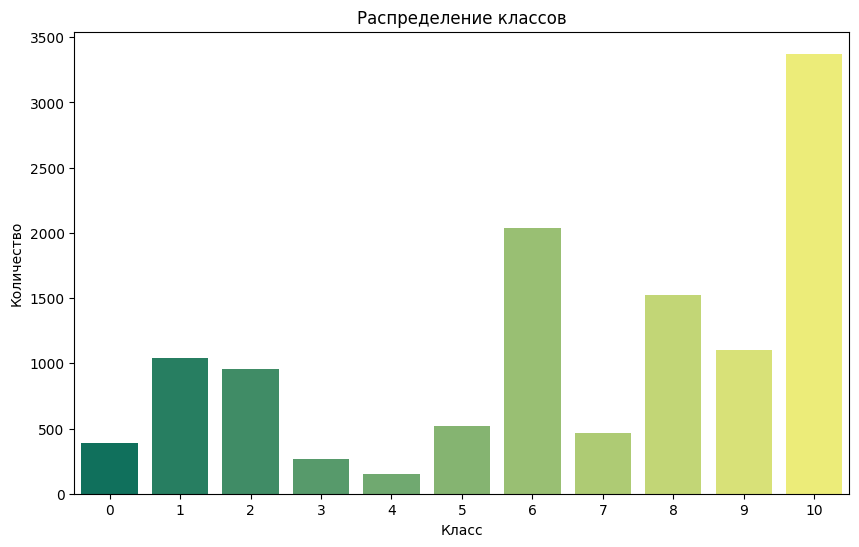

In [22]:
class_distribution = encoded_and_normalized_data['Class'].value_counts()
print("Распределение классов:")
print(class_distribution)

plt.figure(figsize=(10, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values,
            hue=class_distribution.index, palette='summer', legend=False)
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

In [23]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter

In [31]:
#  X - признаки, Y - вектор целевой переменной
X = encoded_and_normalized_data.drop(columns=target + ["Class"], axis = 1)
Y = encoded_and_normalized_data["Class"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42
)

print(Y_train)

print("До SMOTE:", Counter(Y_train))

smoteenn = SMOTE(random_state=42)
X_smote, Y_smote = smoteenn.fit_resample(X_train, Y_train)

print("После SMOTE:", Counter(Y_smote))

14739     9
17443     6
53        1
11823     8
10462     9
         ..
17222     0
7901      9
8210      8
1343      5
11020    10
Name: Class, Length: 9450, dtype: int64
До SMOTE: Counter({10: 2686, 6: 1632, 8: 1217, 9: 884, 1: 810, 2: 769, 5: 423, 7: 381, 0: 319, 3: 212, 4: 117})
После SMOTE: Counter({9: 2686, 6: 2686, 1: 2686, 8: 2686, 3: 2686, 10: 2686, 0: 2686, 7: 2686, 5: 2686, 2: 2686, 4: 2686})


# 12. Исключение коррелированных переменных

Исключение высококоррелированных переменных может:
- уменьшить мультиколлинеарность
- стабилизировать коэффициенты и улучшить обобщающую способность моделей, склонных к переобучению
- сократить размерность признакового пространства.

12.1 Удаление высококоррелированных переменных

In [32]:
ny = []
for i in range(len(target)):
    ny.append([])
for i in range(len(Y_smote)):
    for j in range(len(target)):
        if Y_smote.iloc[i] == j:
            ny[j].append(1)
        else:
            ny[j].append(0)
Y_smote = pd.DataFrame()
i = 0
for col in target:
    Y_smote[col] = ny[i]
    i += 1

ny = []
for i in range(len(target)):
    ny.append([])
for i in range(len(Y_test)):
    for j in range(len(target)):
        if Y_test.iloc[i] == j:
            ny[j].append(1)
        else:
            ny[j].append(0)
Y_test = pd.DataFrame()
i = 0
for col in target:
    Y_test[col] = ny[i]
    i += 1


# to_drop = ['acousticness']
#to_drop = ['loudness', 'energy']

#X_smote = X_smote.drop(columns = to_drop)

# Получаем уменьшенный массив
data_reduced = X_smote.join(Y_smote, how='left')
data_reduced.info()
data_reduced.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29546 entries, 0 to 29545
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Popularity          29546 non-null  float64
 1   danceability        29546 non-null  float64
 2   energy              29546 non-null  float64
 3   key                 29546 non-null  float64
 4   loudness            29546 non-null  float64
 5   mode                29546 non-null  float64
 6   speechiness         29546 non-null  float64
 7   acousticness        29546 non-null  float64
 8   instrumentalness    29546 non-null  float64
 9   liveness            29546 non-null  float64
 10  valence             29546 non-null  float64
 11  tempo               29546 non-null  float64
 12  duration_in min/ms  29546 non-null  float64
 13  time_signature      29546 non-null  float64
 14  Rock                29546 non-null  int64  
 15  Indie               29546 non-null  int64  
 16  Alt 

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,Indie,Alt,Pop,Metal,HipHop,Alt_Music,Blues,Acoustic/Folk,Instrumental,Country
0,-0.066433,1.668957,-0.327282,1.271599,0.492701,-1.288172,0.202019,-0.612820,-0.588986,0.443882,...,0,0,0,0,0,0,0,0,1,0
1,1.382160,1.524383,0.943798,-1.254280,0.392453,0.776294,-0.383698,-0.743174,-0.475619,-1.056716,...,0,0,0,0,0,1,0,0,0,0
2,0.235357,0.524416,0.782849,0.640130,-0.226251,0.776294,-0.399927,-0.744021,-0.584146,-0.232232,...,1,0,0,0,0,0,0,0,0,0
3,-0.187149,-1.162275,1.327598,0.955864,0.624084,0.776294,0.559055,-0.751938,0.790031,-0.376220,...,0,0,0,0,0,0,0,1,0,0
4,2.046099,1.181021,0.308258,0.324395,1.110462,-1.288172,-0.509104,-0.278785,-0.589178,1.107476,...,0,0,0,0,0,0,0,0,1,0


12.2 Тест kNN

In [34]:
best_knn.fit(X_smote, Y_smote)
y_pred_best = best_knn.predict(X_test)

r_test = Y_test.to_numpy().argmax(axis=1)
rpred_best = []
for i in range(len(y_pred_best)):
    rpred_best.append(np.argmax(np.array(y_pred_best[i])))

accuracy_best = accuracy_score(r_test, rpred_best)
print("\nТочность классификатора k-NN:", accuracy_best)

print("\nОтчет о классификации:")
print(classification_report(r_test, rpred_best))

print("\nМатрица ошибок:")
print(confusion_matrix(r_test, rpred_best))


Точность классификатора k-NN: 0.3224714346170123

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.55      0.64      0.59        67
           1       0.07      0.09      0.08       227
           2       0.27      0.29      0.28       187
           3       0.72      0.67      0.70        58
           4       0.39      0.52      0.44        31
           5       0.46      0.53      0.50        94
           6       0.19      0.17      0.18       407
           7       0.82      0.87      0.84        83
           8       0.44      0.48      0.46       306
           9       0.26      0.30      0.28       215
          10       0.35      0.27      0.30       688

    accuracy                           0.32      2363
   macro avg       0.41      0.44      0.42      2363
weighted avg       0.33      0.32      0.32      2363


Матрица ошибок:
[[ 43   0   1   6   9   1   0   5   0   1   1]
 [  0  20   7   0   0   5  99   2  12  21  61]
 [

In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_smote)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, Y_smote, test_size=0.2, random_state=42)

best_knn.fit(X_train_pca, y_train_pca)

y_pred_pca = best_knn.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)
print("\nТочность после применения PCA:", accuracy_pca)


Точность после применения PCA: 0.3730964467005076


#13. Заключение
Наилучшая точность 0.33 была после у k-NN. После применения PCA точность выросла до 0.37. Скорее всего это связано с неточностью определения параметров датасета и плохой структурированности(не имеющего точного параметрического определения) целевого признака.